# 행렬·미분·최적화: 평가 #1~6, #9~12 실행 증거

개념·생활 예시·코드별 순서는 [통합 설명 문서](../docs/code_walkthrough.html)에 정리했다.
모든 그림은 실제 src/ 함수가 반환한 Figure이며 PNG로 저장된 동일 실험 결과다.
원형 lr=.5의 수렴과 타원 lr=.5의 발산은 함수·곡률이 다른 두 실험으로 구분한다.

In [1]:
from pathlib import Path
import sys, os, json
ROOT=Path.cwd()
if ROOT.name=='notebooks': ROOT=ROOT.parent
sys.path.insert(0,str(ROOT))
os.environ['MPLCONFIGDIR']=str(ROOT/'.cache'/'matplotlib')
import numpy as np
np.random.seed(42)
import matplotlib.pyplot as plt
plt.rcParams['axes.prop_cycle']=plt.cycler(color=['#14213d','#a67c20','#64748b','#1d4ed8'])
from src.linear_algebra import plot_transformations, plot_svd_reconstructions, power_iteration
from src.calculus import plot_gradient, plot_derivative_sensitivity
from src.optimizer import VanillaGD, Momentum, optimize, circle_gradient, circle_loss, ellipse_gradient, ellipse_loss, plot_paths, plot_loss_curves
from scripts.assessment import compare_power_iteration
metrics=json.loads((ROOT/'reports'/'metrics.json').read_text())
print('Python:',sys.executable)
print('seed=42; initial=(5,5); fresh optimizer per run; zero initial velocity')

Python: /Users/oliverjoo/Dev/Anaconda/anaconda3/envs/py312/bin/python
seed=42; initial=(5,5); fresh optimizer per run; zero initial velocity


## 1~2. 행렬 변환과 면적 검증

동일한 (100,2) 점 집합의 전후 면적을 신발끈 공식으로 계산한다. 세 서브플롯의 파라미터·면적·비율·상대오차·PASS를 확인한다.

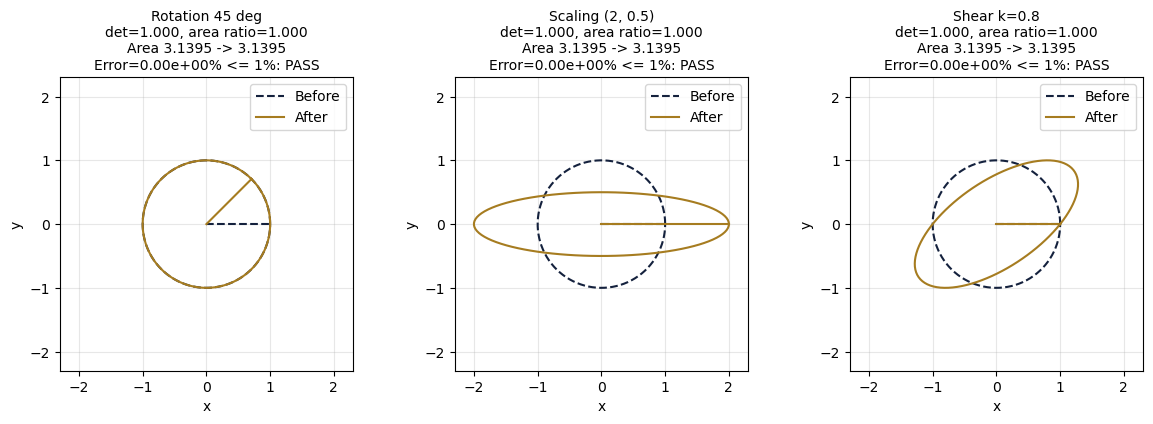

{
  "rotation": {
    "parameters": [
      [
        0.7071067811865476,
        -0.7071067811865475
      ],
      [
        0.7071067811865475,
        0.7071067811865476
      ]
    ],
    "determinant": 1.0,
    "points_shape": [
      100,
      2
    ],
    "sample_count": 100,
    "distinct_vertices": 99,
    "before_area": 3.1394840229999432,
    "after_area": 3.1394840229999432,
    "measured_area_ratio": 1.0,
    "relative_error_percent": 0.0,
    "tolerance_percent": 1.0,
    "passed": true
  },
  "scaling": {
    "parameters": [
      [
        2.0,
        0.0
      ],
      [
        0.0,
        0.5
      ]
    ],
    "determinant": 1.0,
    "points_shape": [
      100,
      2
    ],
    "sample_count": 100,
    "distinct_vertices": 99,
    "before_area": 3.1394840229999432,
    "after_area": 3.1394840229999432,
    "measured_area_ratio": 1.0,
    "relative_error_percent": 0.0,
    "tolerance_percent": 1.0,
    "passed": true
  },
  "shear": {
    "parameters": [
     

In [2]:
figure=plot_transformations()
plt.show()
print(json.dumps(metrics['area'],indent=2))

## 3. 고유값·고유벡터 비교

A=[[4,1],[1,3]]. 직접 반복한 해와 검증 전용 eig를 비교한다. v와 -v의 부호 모호성을 정렬한 뒤 오차를 확인한다.

In [3]:
A=np.array([[4.,1.],[1.,3.]])
value,vector,iterations=power_iteration(A)
comparison=compare_power_iteration(A,value,vector)
print('A=',A,'shape=',A.shape,'lambda=',value,'vector=',vector,'iterations=',iterations)
print(json.dumps(comparison,indent=2))
assert comparison['passed'] and comparison['vector_passed']

A= [[4. 1.]
 [1. 3.]] shape= (2, 2) lambda= 4.618033988749502 vector= [0.85065059 0.52573147] iterations= 20
{
  "reference_eig": 4.618033988749895,
  "reference_eigenvector": [
    0.85065080835204,
    0.5257311121191336
  ],
  "relative_error_percent": 8.500908881654326e-12,
  "tolerance_percent": 5.0,
  "passed": true,
  "sign_aligned_vector_l2_error": 4.1937813329955695e-07,
  "vector_tolerance": 1e-06,
  "vector_passed": true,
  "residual_norm": 9.377580143164632e-07,
  "residual_tolerance": 1e-06,
  "residual_passed": true
}


## 4. SVD 요청과 실제 성분 수

원본 (64,64)의 성분은 최대 64개. 요청 10/50/100은 실제 10/50/64개이며 MSE와 값 개수 비율을 같이 읽는다.

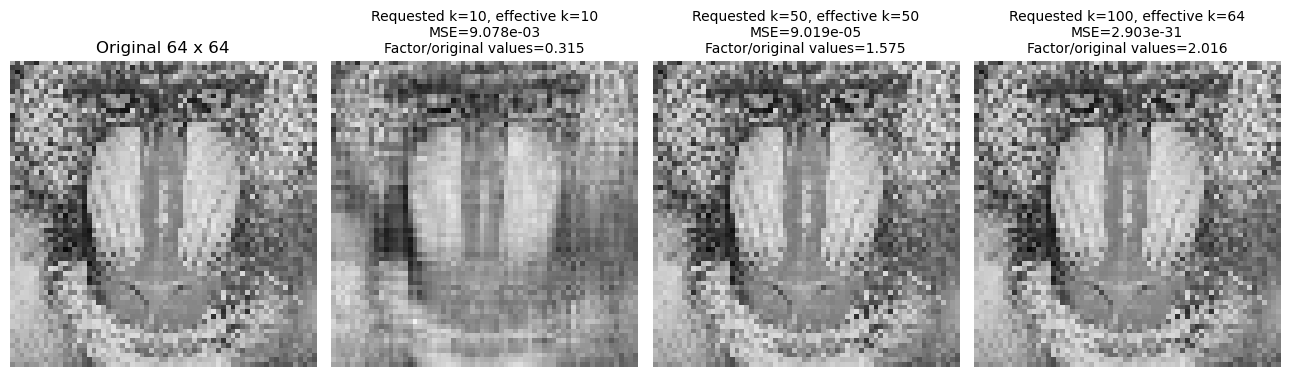

image shape= (64, 64)
[
  {
    "requested_k": 10,
    "effective_k": 10,
    "image_shape": [
      64,
      64
    ],
    "mse": 0.009078435873897225,
    "max_absolute_pixel_error": 0.4274169368339865,
    "rank_cap": 64,
    "factor_to_original_ratio": 0.31494140625,
    "original_values": 4096,
    "factor_values": 1290
  },
  {
    "requested_k": 50,
    "effective_k": 50,
    "image_shape": [
      64,
      64
    ],
    "mse": 9.018560609664049e-05,
    "max_absolute_pixel_error": 0.04590962147235289,
    "rank_cap": 64,
    "factor_to_original_ratio": 1.57470703125,
    "original_values": 4096,
    "factor_values": 6450
  },
  {
    "requested_k": 100,
    "effective_k": 64,
    "image_shape": [
      64,
      64
    ],
    "mse": 2.9025612139035137e-31,
    "max_absolute_pixel_error": 4.3298697960381105e-15,
    "rank_cap": 64,
    "factor_to_original_ratio": 2.015625,
    "original_values": 4096,
    "factor_values": 8256
  }
]


In [4]:
image=np.load(ROOT/'data'/'image64.npy')
figure=plot_svd_reconstructions(image)
plt.show()
print('image shape=',image.shape)
print(json.dumps(metrics['svd'],indent=2))

## 5. 중심차분의 h 민감도

x²는 대수적으로 중심차분이 정확해 절단오차의 O(h²)를 관찰하기 어렵다. 보조 sin(x)에서는 h=.1→.01→.001에서 오차가 대략 100분의 1이 된다. 아주 작은 h에서는 뺄셈 오차가 커질 수 있다.

Required derivative: {
  "value": 6.000000000039306,
  "analytic_value": 6.0,
  "h": 1e-05,
  "absolute_error": 3.930633596382904e-11,
  "tolerance": 0.0001,
  "passed": true
}
{'function': 'x^2', 'x': 3.0, 'h': 0.1, 'numeric': 6.000000000000005, 'analytic': 6.0, 'absolute_error': 5.329070518200751e-15, 'tolerance': 0.0001, 'passed': True}
{'function': 'x^2', 'x': 3.0, 'h': 0.01, 'numeric': 5.999999999999872, 'analytic': 6.0, 'absolute_error': 1.2789769243681803e-13, 'tolerance': 0.0001, 'passed': True}
{'function': 'x^2', 'x': 3.0, 'h': 0.001, 'numeric': 5.999999999999339, 'analytic': 6.0, 'absolute_error': 6.608047442568932e-13, 'tolerance': 0.0001, 'passed': True}
{'function': 'x^2', 'x': 3.0, 'h': 1e-05, 'numeric': 6.000000000039306, 'analytic': 6.0, 'absolute_error': 3.930633596382904e-11, 'tolerance': 0.0001, 'passed': True}
{'function': 'x^2', 'x': 3.0, 'h': 1e-07, 'numeric': 5.999999990180527, 'analytic': 6.0, 'absolute_error': 9.819473234529141e-09, 'tolerance': 0.0001, 'passe

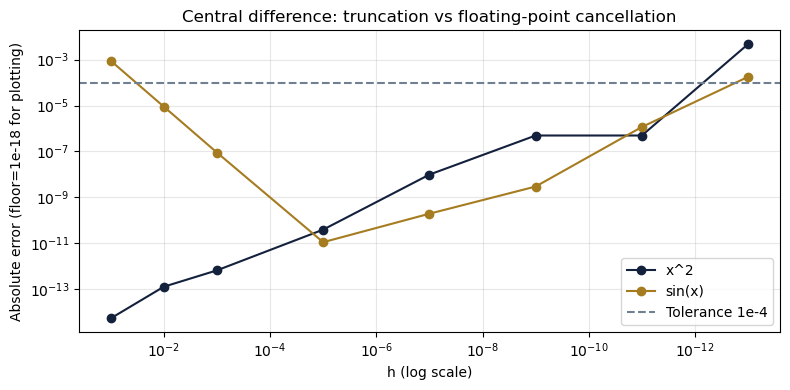

In [5]:
print('Required derivative:',json.dumps(metrics['derivative'],indent=2))
for row in metrics['derivative_sensitivity']: print(row)
figure=plot_derivative_sensitivity(metrics['derivative_sensitivity'])
plt.show()

## 6. 기울기의 방향과 화살표 스케일

f=4의 원 위 8점의 실제 기울기 크기는 4. scale=5로 표시 길이는 .8이다. 내적 0은 접선과 수직임을 뜻한다.

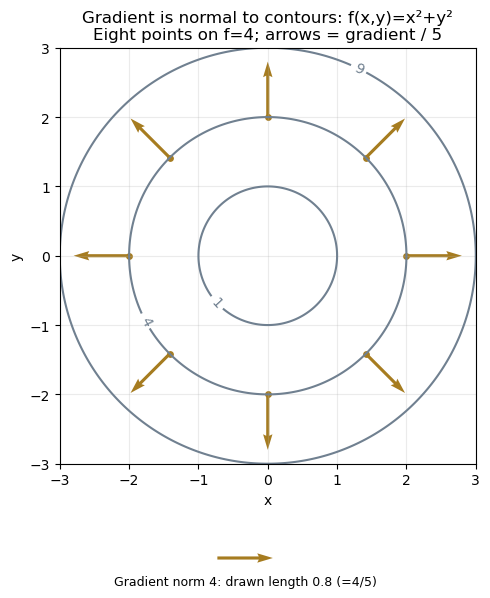

{'points_shape': [8, 2], 'contour_levels': [1, 4, 9], 'gradient_norm_on_radius_2': 4.0, 'quiver_scale': 5.0, 'displayed_arrow_length': 0.8}
tangent absolute dot: [0.0, 0.0, 1.7763568394002505e-15]


In [6]:
figure=plot_gradient()
plt.show()
print(metrics['gradient_visualization'])
print('tangent absolute dot:',metrics['gradient_tangent_abs_dot'])

## 9·11. 원형 함수의 동일 조건 비교

GD와 Momentum은 같은 초기점과 lr=.1, 100회다. PDF의 수렴 기준은 반경 .1이며 초기점까지 합쳐 101개 좌표를 저장한다.

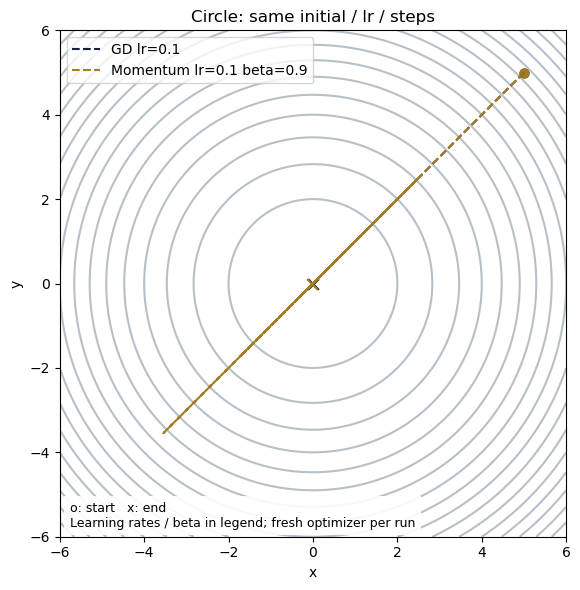

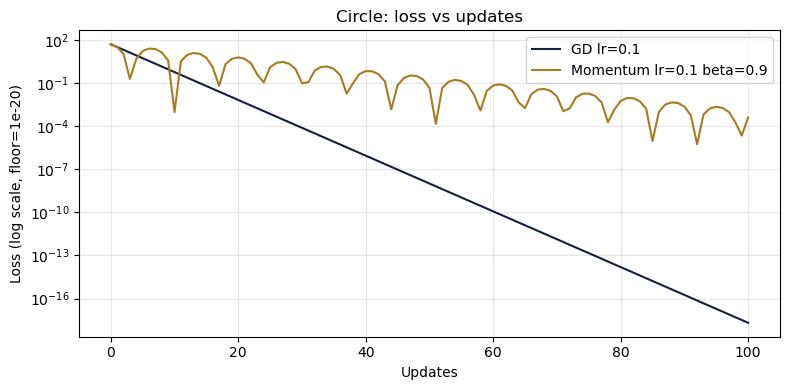

{
  "GD lr=0.1": {
    "final_point": [
      1.0185179881672439e-09,
      1.0185179881672439e-09
    ],
    "final_loss": 2.0747577844404998e-18,
    "final_radius": 1.4404019523870759e-09,
    "first_update_loss_le_0.01": 20,
    "first_sustained_update_loss_le_0.01": 20,
    "radius_threshold_pdf": 0.1,
    "within_pdf_radius_0.1": true,
    "within_review_radius_1": true,
    "updates": 100
  },
  "Momentum lr=0.1 beta=0.9": {
    "final_point": [
      -0.01425705560591328,
      -0.01425705560591328
    ],
    "final_loss": 0.0004065272691002066,
    "final_radius": 0.020162521397389926,
    "first_update_loss_le_0.01": 10,
    "first_sustained_update_loss_le_0.01": 77,
    "radius_threshold_pdf": 0.1,
    "within_pdf_radius_0.1": true,
    "within_review_radius_1": true,
    "updates": 100
  }
}


In [7]:
paths={'GD lr=0.1':optimize(VanillaGD(.1),circle_gradient,steps=100), 'Momentum lr=0.1 beta=0.9':optimize(Momentum(.1,.9),circle_gradient,steps=100)}
figure=plot_paths(circle_loss,paths,'Circle: same initial / lr / steps')
plt.show()
figure=plot_loss_curves(circle_loss,paths,'Circle: loss vs updates')
plt.show()
print(json.dumps(metrics['circle'],indent=2))
assert metrics['circle']['GD lr=0.1']['within_pdf_radius_0.1']

## 10. 함수별 발산 경계

원형의 배율 1−2lr는 lr=.5에서 0이다. 초기값을 키워도 이 사실은 변하지 않는다. 타원의 y 배율은 1−20lr여서 lr=.5에서는 −9, 매번 y² 손실이 81배 증가한다.

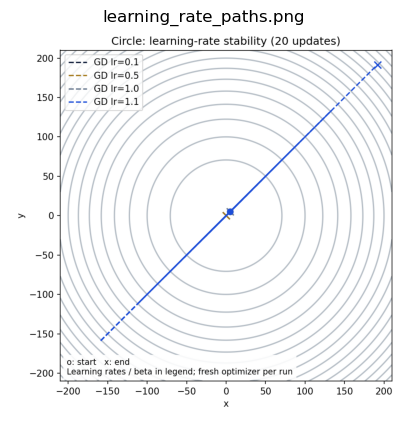

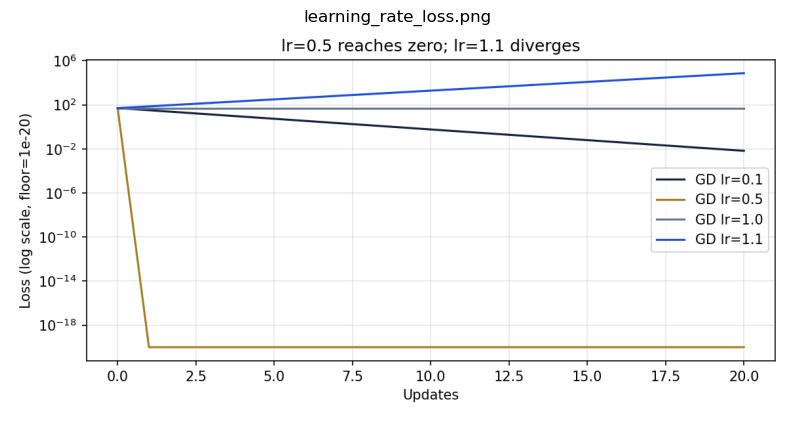

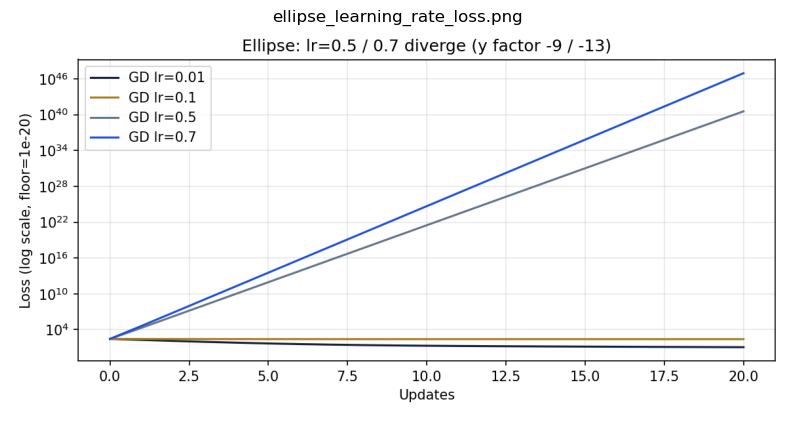

[
  {
    "learning_rate": 0.1,
    "coordinate_factor": 0.8,
    "regime": "convergent",
    "radius_ratio": 0.01152921504606847,
    "predicted_radius_ratio": 0.011529215046068483,
    "matches_recurrence": true,
    "divergence_observed": false
  },
  {
    "learning_rate": 0.5,
    "coordinate_factor": 0.0,
    "regime": "convergent",
    "radius_ratio": 0.0,
    "predicted_radius_ratio": 0.0,
    "matches_recurrence": true,
    "divergence_observed": false
  },
  {
    "learning_rate": 1.0,
    "coordinate_factor": -1.0,
    "regime": "oscillating",
    "radius_ratio": 1.0,
    "predicted_radius_ratio": 1.0,
    "matches_recurrence": true,
    "divergence_observed": false
  },
  {
    "learning_rate": 1.1,
    "coordinate_factor": -1.2000000000000002,
    "regime": "divergent",
    "radius_ratio": 38.33759992447485,
    "predicted_radius_ratio": 38.337599924474866,
    "matches_recurrence": true,
    "divergence_observed": true
  }
]
{
  "GD lr=0.01": {
    "final_point": [
      

In [8]:
for filename in ['learning_rate_paths.png','learning_rate_loss.png','ellipse_learning_rate_loss.png']:
    plt.figure(figsize=(10,5)); plt.imshow(plt.imread(ROOT/'outputs'/filename)); plt.axis('off'); plt.title(filename); plt.show()
print(json.dumps(metrics['learning_rate_stability'],indent=2))
print(json.dumps(metrics['ellipse_learning_rates'],indent=2))
assert metrics['ellipse_stability']['loss_increases_at_lr_0.5']

## 12. 타원에서 Momentum의 이점과 진동

같은 lr=.01, β=.9, 200회. 첫 .01 도달과 이후 관측 구간에서 계속 유지하는 최초 업데이트를 따로 비교한다.

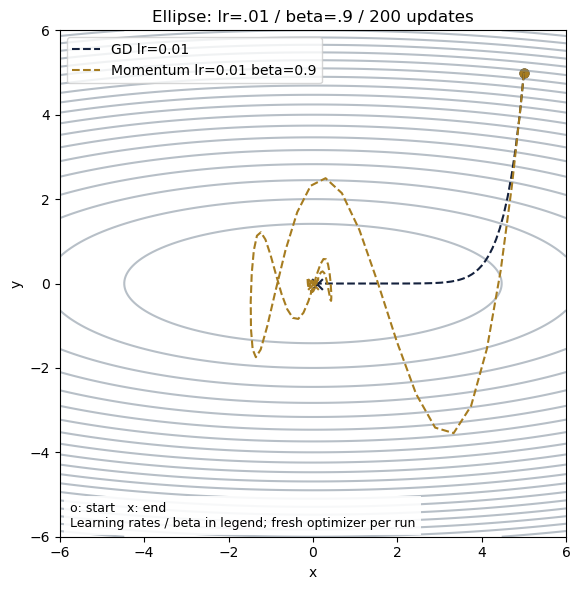

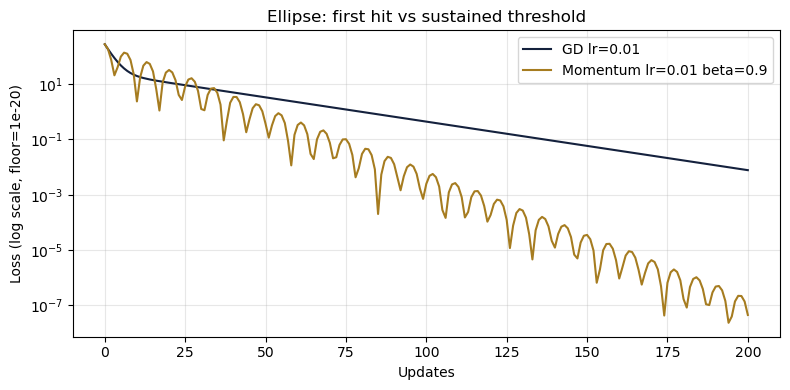

{
  "GD lr=0.01": {
    "final_point": [
      0.08793973302860783,
      2.074757784440498e-19
    ],
    "final_loss": 0.0077333966451428185,
    "final_radius": 0.08793973302860783,
    "first_update_loss_le_0.01": 194,
    "first_sustained_update_loss_le_0.01": 194,
    "radius_threshold_pdf": 0.1,
    "within_pdf_radius_0.1": true,
    "within_review_radius_1": true,
    "updates": 200
  },
  "Momentum lr=0.01 beta=0.9": {
    "final_point": [
      -1.0332674615785416e-05,
      -6.710158824490631e-05
    ],
    "final_loss": 4.513299561460518e-08,
    "final_radius": 6.789246872595403e-05,
    "first_update_loss_le_0.01": 78,
    "first_sustained_update_loss_le_0.01": 97,
    "radius_threshold_pdf": 0.1,
    "within_pdf_radius_0.1": true,
    "within_review_radius_1": true,
    "updates": 200
  }
}


In [9]:
paths={'GD lr=0.01':optimize(VanillaGD(.01),ellipse_gradient,steps=200), 'Momentum lr=0.01 beta=0.9':optimize(Momentum(.01,.9),ellipse_gradient,steps=200)}
figure=plot_paths(ellipse_loss,paths,'Ellipse: lr=.01 / beta=.9 / 200 updates')
plt.show()
figure=plot_loss_curves(ellipse_loss,paths,'Ellipse: first hit vs sustained threshold')
plt.show()
print(json.dumps(metrics['ellipse'],indent=2))